# Credit Scoring Model - Exploratory Data Analysis

## Project Overview
This notebook performs comprehensive exploratory data analysis on historical credit data to identify key risk factors that predict borrower default within the next two years. The insights will inform the development of a credit scoring model for inclusive finance in Ethiopia.

**Business Objective**: Predict the likelihood of a borrower experiencing financial distress (90+ days past due) within 2 years.

**Dataset**: 150,000 anonymized borrower records with demographic, credit utilization, payment history, and financial metrics.

---

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Import custom utility functions
from eda_utils import (
    load_data, basic_info, data_quality_report, detect_outliers,
    plot_distribution, plot_categorical, correlation_analysis,
    plot_target_relationship, calculate_woe_iv, statistical_test
)

# Configure visualization settings
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load the credit scoring dataset
df = load_data('../data/cs-training.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 150,000 rows × 12 columns

First 5 rows:


,BorrowerID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


---
## 2. Data Quality Assessment

In [3]:
# Comprehensive data overview
basic_info(df)

DATASET OVERVIEW
Dataset Shape: 150,000 rows × 12 columns
Memory Usage: 13.73 MB

DATA TYPES
BorrowerID                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

MISSING VALUES SUMMARY
                    Missing_Count  Percentage
MonthlyIncome               29731       19.82
NumberOfDependents           3924        2.62

NUMERICAL FEATURES STATISTICS
          BorrowerID  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000      

In [4]:
# Detailed data quality report
quality_report = data_quality_report(df)
print("\nData Quality Report:")
print("=" * 100)
quality_report


Data Quality Report:


,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values,Sample_Values
6,MonthlyIncome,float64,29731,19.820667,13594,"[9120.0, 2600.0, 3042.0]"
11,NumberOfDependents,float64,3924,2.616000,13,"[2.0, 1.0, 0.0]"
0,BorrowerID,int64,0,0.000000,150000,"[1, 2, 3]"
1,SeriousDlqin2yrs,int64,0,0.000000,2,"[1, 0, 0]"
3,age,int64,0,0.000000,86,"[45, 40, 38]"
2,RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000,125728,"[0.766126609, 0.957151019, 0.65818014]"
5,DebtRatio,float64,0,0.000000,114194,"[0.802982129, 0.121876201, 0.085113375]"
4,NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000,16,"[2, 0, 1]"
7,NumberOfOpenCreditLinesAndLoans,int64,0,0.000000,58,"[13, 4, 2]"
8,NumberOfTimes90DaysLate,int64,0,0.000000,19,"[0, 0, 1]"


### Key Findings - Data Quality
- Document missing value patterns
- Identify data type issues
- Note any data anomalies

---
## 3. Target Variable Analysis

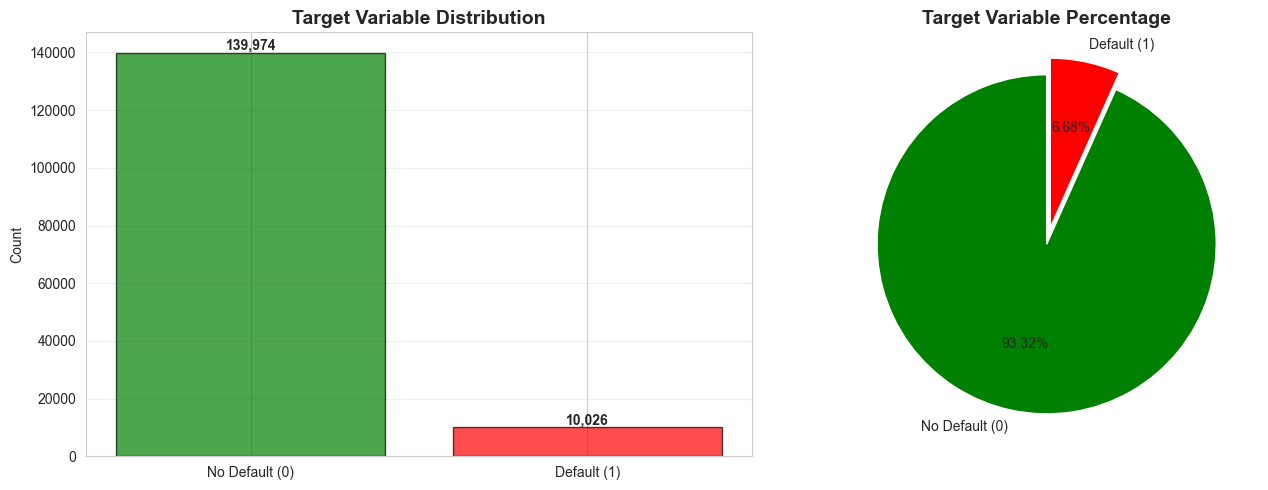


Class Imbalance Ratio: 1:13.96
⚠️ Note: Significant class imbalance detected. Consider using SMOTE, class weights, or stratified sampling.


In [5]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['SeriousDlqin2yrs'].value_counts()
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values, 
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
axes[1].pie(target_pct.values, labels=['No Default (0)', 'Default (1)'], 
            autopct='%1.2f%%', colors=['green', 'red'], startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Target Variable Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.2f}")
print("⚠️ Note: Significant class imbalance detected. Consider using SMOTE, class weights, or stratified sampling.")

---
## 4. Univariate Analysis - Numerical Features

In [6]:
# Define numerical features
numerical_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

print(f"Analyzing {len(numerical_features)} numerical features...")

Analyzing 10 numerical features...


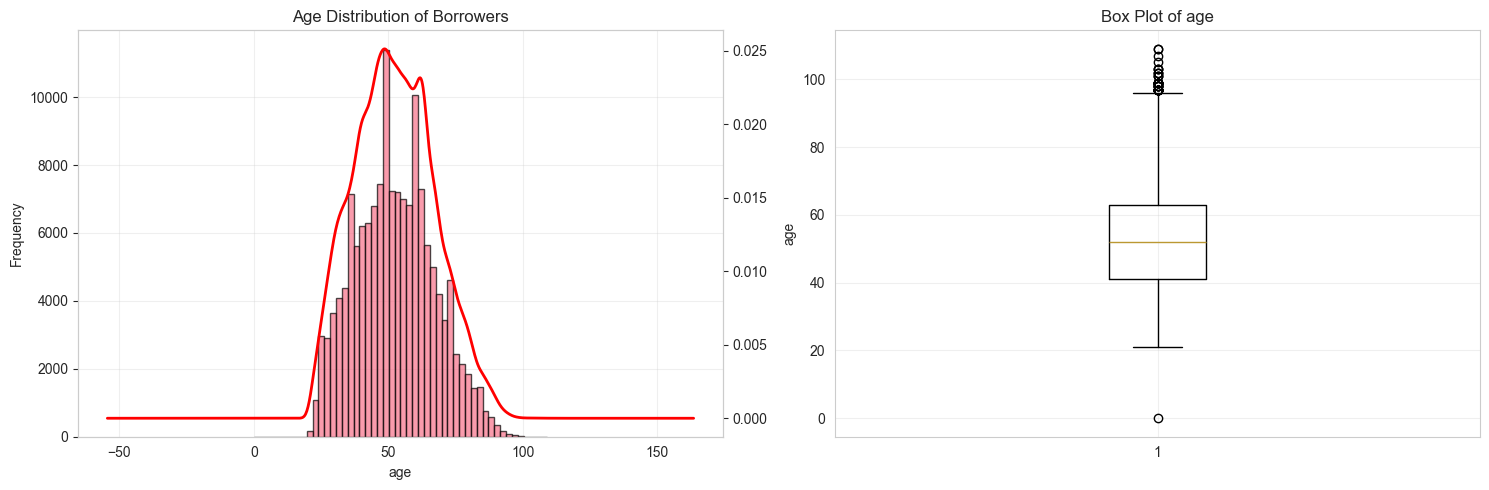


Age Statistics:
  Mean: 52.3 years
  Median: 52.0 years
  Range: 0 - 109 years


In [7]:
# Age distribution
fig = plot_distribution(df, 'age', 'Age Distribution of Borrowers')
plt.show()

print(f"\nAge Statistics:")
print(f"  Mean: {df['age'].mean():.1f} years")
print(f"  Median: {df['age'].median():.1f} years")
print(f"  Range: {df['age'].min():.0f} - {df['age'].max():.0f} years")

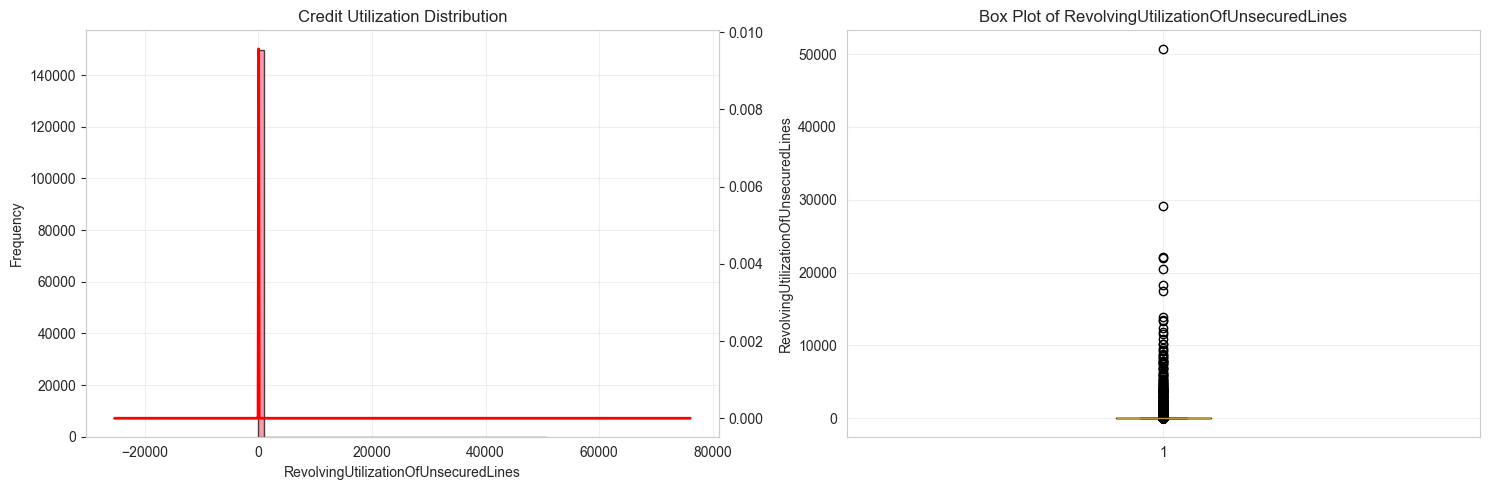


Borrowers with over-utilization (>100%): 3,321 (2.21%)
⚠️ Over-utilization indicates borrowers exceeding their credit limits - high risk indicator


In [8]:
# Revolving utilization analysis
fig = plot_distribution(df, 'RevolvingUtilizationOfUnsecuredLines', 
                       'Credit Utilization Distribution')
plt.show()

# Check for over-utilization (>1.0)
over_util = (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()
over_util_pct = (over_util / len(df)) * 100
print(f"\nBorrowers with over-utilization (>100%): {over_util:,} ({over_util_pct:.2f}%)")
print("⚠️ Over-utilization indicates borrowers exceeding their credit limits - high risk indicator")

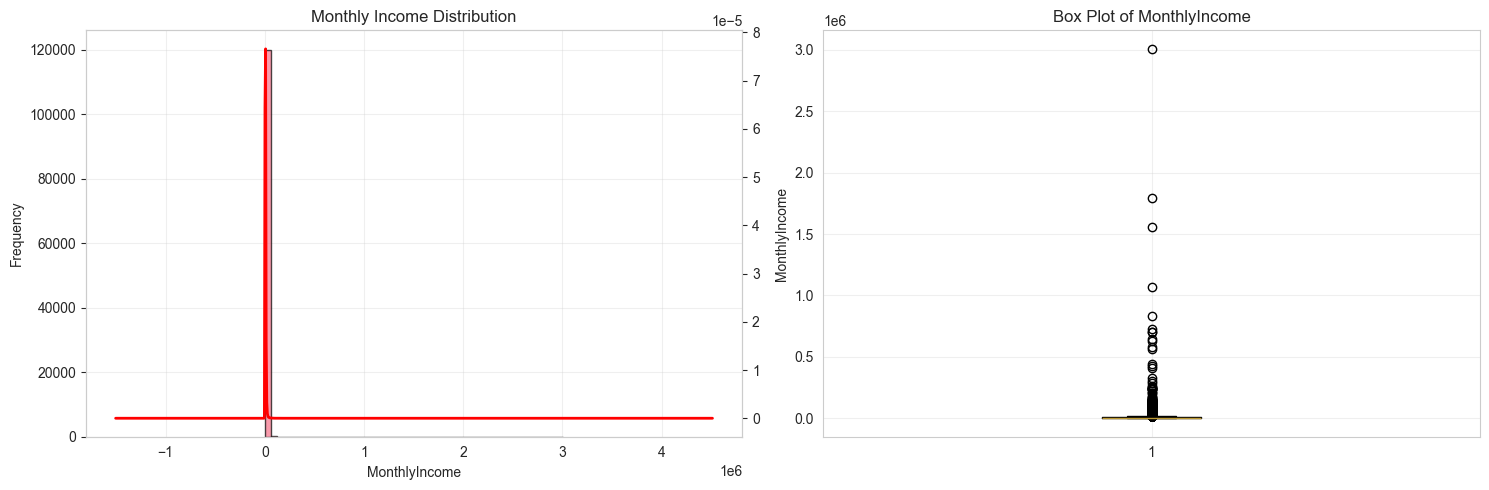


Monthly Income Statistics:
  Mean: $6,670.22
  Median: $5,400.00
  Missing: 29,731 (19.82%)


In [9]:
# Monthly income distribution
fig = plot_distribution(df, 'MonthlyIncome', 'Monthly Income Distribution')
plt.show()

print(f"\nMonthly Income Statistics:")
print(f"  Mean: ${df['MonthlyIncome'].mean():,.2f}")
print(f"  Median: ${df['MonthlyIncome'].median():,.2f}")
print(f"  Missing: {df['MonthlyIncome'].isnull().sum():,} ({df['MonthlyIncome'].isnull().sum()/len(df)*100:.2f}%)")

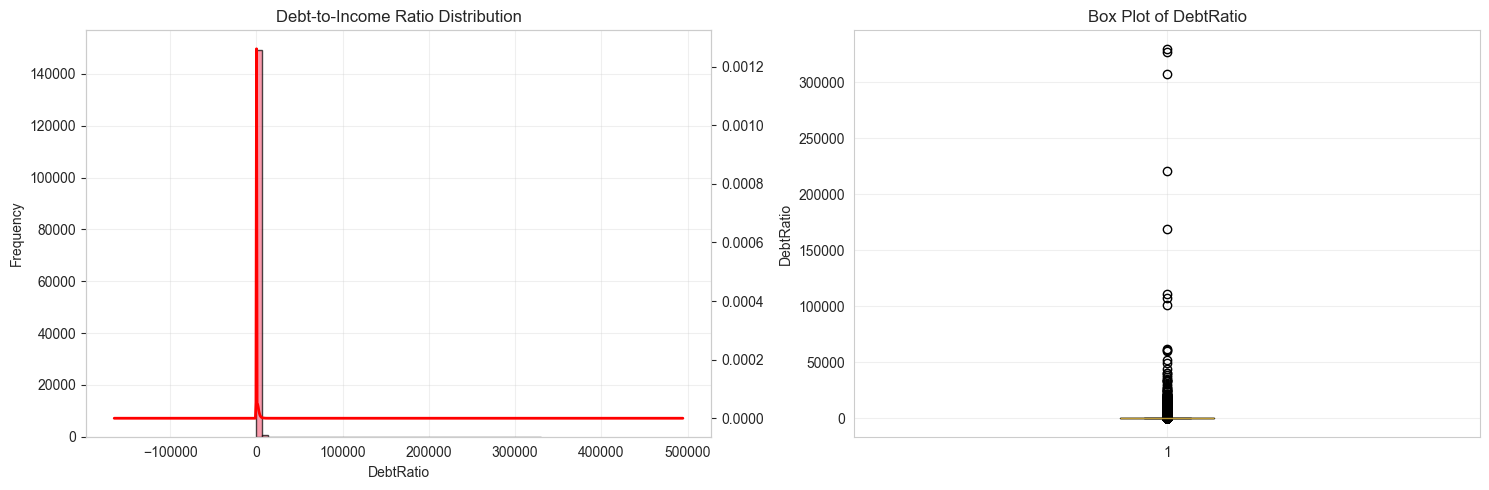


Debt Ratio Categories:
  Low (<36%): 73,861 (49.24%)
  Medium (36-50%): 19,841 (13.23%)
  High (>50%): 56,298 (37.53%)


In [10]:
# Debt ratio analysis
fig = plot_distribution(df, 'DebtRatio', 'Debt-to-Income Ratio Distribution')
plt.show()

# Categorize debt levels
low_debt = (df['DebtRatio'] < 0.36).sum()
medium_debt = ((df['DebtRatio'] >= 0.36) & (df['DebtRatio'] < 0.5)).sum()
high_debt = (df['DebtRatio'] >= 0.5).sum()

print(f"\nDebt Ratio Categories:")
print(f"  Low (<36%): {low_debt:,} ({low_debt/len(df)*100:.2f}%)")
print(f"  Medium (36-50%): {medium_debt:,} ({medium_debt/len(df)*100:.2f}%)")
print(f"  High (>50%): {high_debt:,} ({high_debt/len(df)*100:.2f}%)")

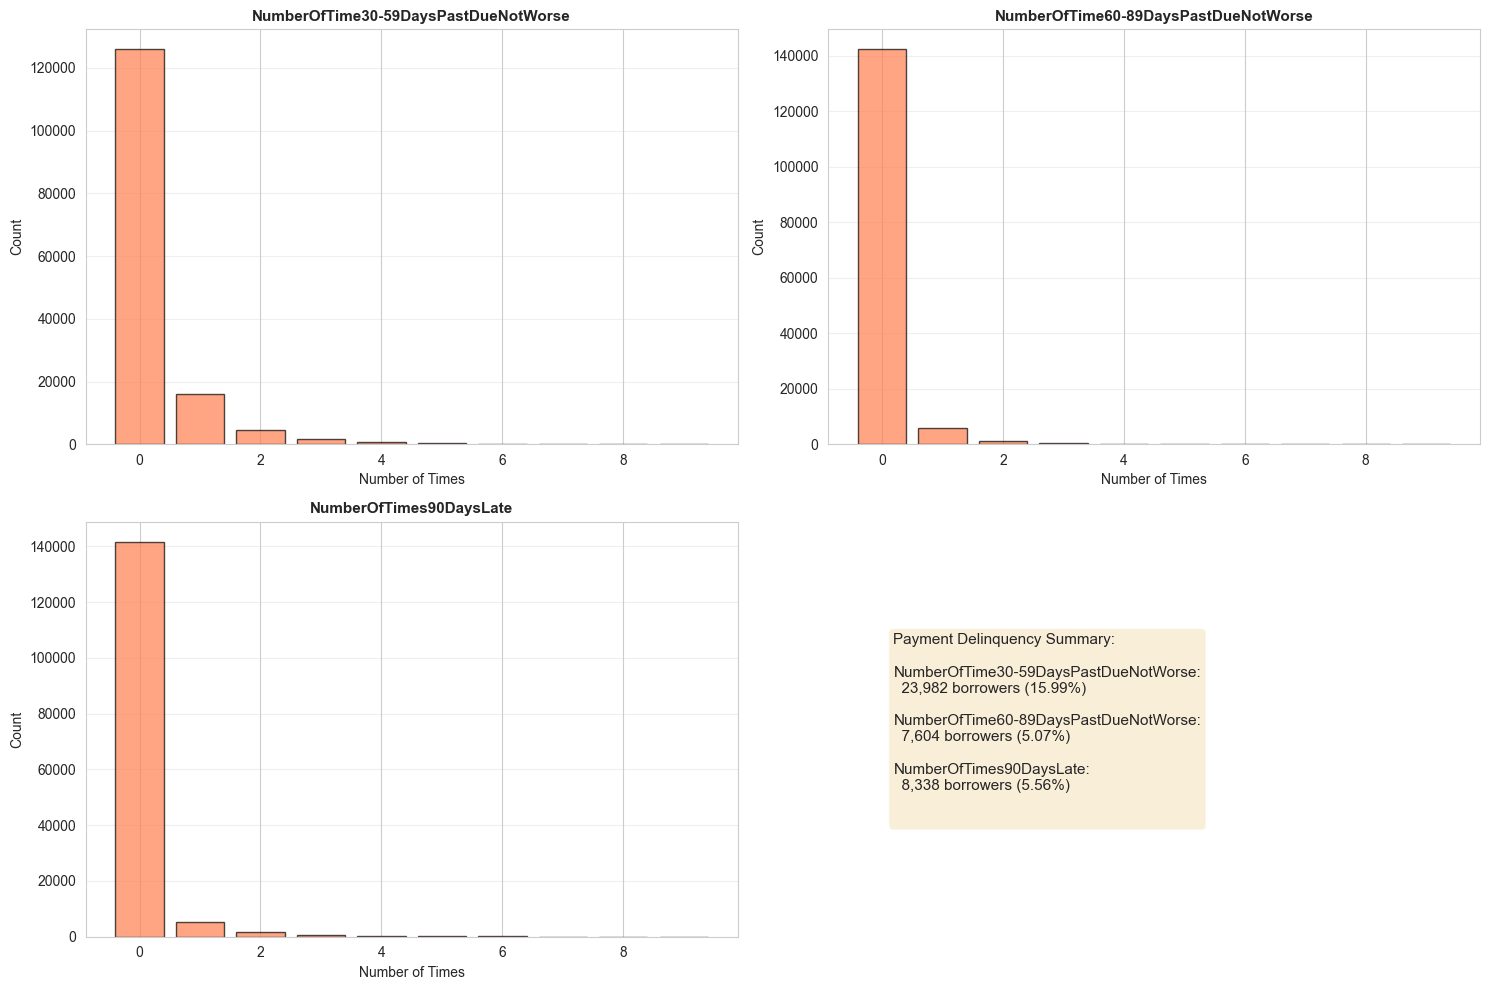

In [11]:
# Payment delinquency analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

delinquency_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for idx, col in enumerate(delinquency_cols):
    row = idx // 2
    col_idx = idx % 2
    
    value_counts = df[col].value_counts().sort_index().head(10)
    axes[row, col_idx].bar(value_counts.index, value_counts.values, 
                           color='coral', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[row, col_idx].set_xlabel('Number of Times')
    axes[row, col_idx].set_ylabel('Count')
    axes[row, col_idx].grid(axis='y', alpha=0.3)

# Summary statistics in the 4th subplot
axes[1, 1].axis('off')
summary_text = "Payment Delinquency Summary:\n\n"
for col in delinquency_cols:
    has_delinq = (df[col] > 0).sum()
    pct = (has_delinq / len(df)) * 100
    summary_text += f"{col}:\n  {has_delinq:,} borrowers ({pct:.2f}%)\n\n"

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

---
## 5. Bivariate Analysis - Feature vs Target

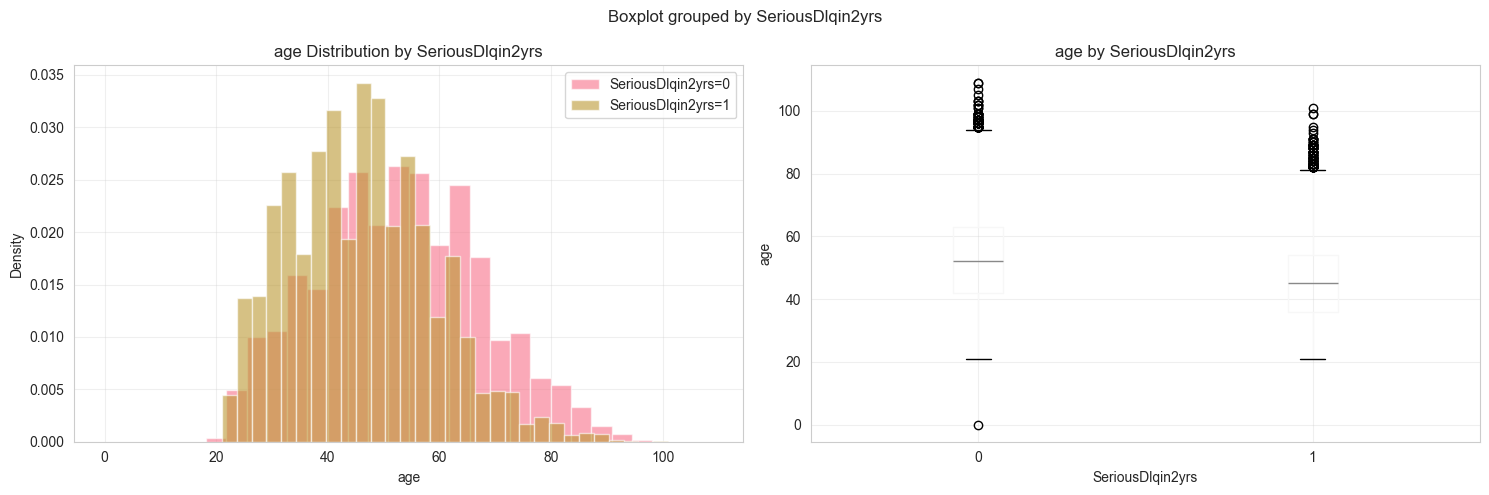


Statistical Test Results for Age:
  Mean age (No Default): 52.75 years
  Mean age (Default): 45.93 years
  P-value: 0.000000
  Statistically significant: Yes


In [12]:
# Age vs Default
fig = plot_target_relationship(df, 'age', 'SeriousDlqin2yrs')
plt.show()

# Statistical test
test_results = statistical_test(df, 'age', 'SeriousDlqin2yrs')
print(f"\nStatistical Test Results for Age:")
print(f"  Mean age (No Default): {test_results['mean_class_0']:.2f} years")
print(f"  Mean age (Default): {test_results['mean_class_1']:.2f} years")
print(f"  P-value: {test_results['p_value_ttest']:.6f}")
print(f"  Statistically significant: {'Yes' if test_results['significant_at_0.05'] else 'No'}")

In [ ]:
# Revolving utilization vs Default
fig = plot_target_relationship(df, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs')
plt.show()

test_results = statistical_test(df, 'RevolvingUtilizationOfUnsecuredLines', 'SeriousDlqin2yrs')
print(f"\nStatistical Test Results for Credit Utilization:")
print(f"  Mean utilization (No Default): {test_results['mean_class_0']:.4f}")
print(f"  Mean utilization (Default): {test_results['mean_class_1']:.4f}")
print(f"  P-value: {test_results['p_value_ttest']:.6f}")
print(f"  Statistically significant: {'Yes' if test_results['significant_at_0.05'] else 'No'}")

In [ ]:
# Debt ratio vs Default
fig = plot_target_relationship(df, 'DebtRatio', 'SeriousDlqin2yrs')
plt.show()

test_results = statistical_test(df, 'DebtRatio', 'SeriousDlqin2yrs')
print(f"\nStatistical Test Results for Debt Ratio:")
print(f"  Mean debt ratio (No Default): {test_results['mean_class_0']:.4f}")
print(f"  Mean debt ratio (Default): {test_results['mean_class_1']:.4f}")
print(f"  P-value: {test_results['p_value_ttest']:.6f}")
print(f"  Statistically significant: {'Yes' if test_results['significant_at_0.05'] else 'No'}")

In [ ]:
# Monthly income vs Default
fig = plot_target_relationship(df, 'MonthlyIncome', 'SeriousDlqin2yrs')
plt.show()

test_results = statistical_test(df, 'MonthlyIncome', 'SeriousDlqin2yrs')
print(f"\nStatistical Test Results for Monthly Income:")
print(f"  Mean income (No Default): ${test_results['mean_class_0']:,.2f}")
print(f"  Mean income (Default): ${test_results['mean_class_1']:,.2f}")
print(f"  P-value: {test_results['p_value_ttest']:.6f}")
print(f"  Statistically significant: {'Yes' if test_results['significant_at_0.05'] else 'No'}")

---
## 6. Multivariate Analysis - Correlation

In [ ]:
# Correlation analysis
fig, corr_matrix = correlation_analysis(df, numerical_features, method='pearson')
plt.show()

# Identify highly correlated features
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
print("=" * 80)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not high_corr:
    print("  No highly correlated feature pairs found.")
else:
    print("\n⚠️ Consider removing one feature from highly correlated pairs to avoid multicollinearity.")

In [ ]:
# Correlation with target variable
target_corr = df[numerical_features + ['SeriousDlqin2yrs']].corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
target_corr_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Feature Correlation with Target Variable (Absolute Values)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.set_ylabel('Features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 Features Correlated with Default:")
print("=" * 80)
for feature, corr_val in target_corr_sorted.head(5).items():
    print(f"  {feature}: {target_corr[feature]:.4f}")

---
## 7. Weight of Evidence (WoE) and Information Value (IV)

In [ ]:
# Calculate WoE and IV for key features
print("Weight of Evidence and Information Value Analysis")
print("=" * 80)

iv_results = {}
for feature in ['age', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    print(f"\n{'='*80}")
    print(f"Feature: {feature}")
    print(f"{'='*80}")
    woe_df = calculate_woe_iv(df, feature, 'SeriousDlqin2yrs', bins=10)
    iv_results[feature] = woe_df['IV'].sum()
    display(woe_df)

In [ ]:
# Visualize Information Values
fig, ax = plt.subplots(figsize=(10, 6))
iv_series = pd.Series(iv_results).sort_values(ascending=False)
colors = ['green' if x > 0.3 else 'orange' if x > 0.1 else 'red' for x in iv_series.values]
iv_series.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Information Value by Feature', fontsize=14, fontweight='bold')
ax.set_xlabel('Information Value (IV)')
ax.set_ylabel('Features')
ax.axvline(x=0.1, color='orange', linestyle='--', label='Weak (0.1)')
ax.axvline(x=0.3, color='green', linestyle='--', label='Strong (0.3)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Outlier Detection

In [ ]:
# Detect outliers using IQR method
print("Outlier Detection Summary (IQR Method)")
print("=" * 80)

outlier_summary = []
for feature in numerical_features:
    if df[feature].dtype in ['float64', 'int64']:
        outliers = detect_outliers(df, feature, method='iqr')
        outlier_count = outliers.sum()
        outlier_pct = (outlier_count / len(df)) * 100
        outlier_summary.append({
            'Feature': feature,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_pct
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
display(outlier_df)

print("\n⚠️ Recommendation: Investigate outliers before model training. Consider:")
print("  - Winsorization (capping at percentiles)")
print("  - Log transformation for skewed distributions")
print("  - Separate treatment for extreme values")

---
## 9. Key Insights and Recommendations

### Summary of Findings

#### 1. Data Quality
- **Missing Values**: [Document missing value patterns]
- **Outliers**: [Document outlier findings]
- **Data Types**: [Document any data type issues]

#### 2. Target Variable
- **Class Imbalance**: [Document imbalance ratio]
- **Recommendation**: Use stratified sampling, SMOTE, or class weights in modeling

#### 3. Key Risk Factors
Based on statistical tests and Information Value:
- **Strong Predictors**: [List features with IV > 0.3]
- **Medium Predictors**: [List features with 0.1 < IV < 0.3]
- **Weak Predictors**: [List features with IV < 0.1]

#### 4. Feature Engineering Recommendations
- Create aggregate delinquency score from payment history features
- Bin continuous variables (age groups, income brackets)
- Create interaction features (e.g., debt_ratio × age)
- Handle missing values in MonthlyIncome and NumberOfDependents

#### 5. Modeling Recommendations
- **Algorithms to try**: Logistic Regression, Random Forest, XGBoost, LightGBM
- **Evaluation metrics**: AUC-ROC, Precision-Recall, F1-Score (due to class imbalance)
- **Cross-validation**: Use stratified k-fold
- **Feature selection**: Remove highly correlated features, use feature importance

#### 6. Business Impact
- Focus on top predictive features for interpretability
- Consider regulatory requirements for model explainability
- Implement monitoring for model drift in production

---

### Next Steps
1. ✅ Complete exploratory data analysis
2. ⏭️ Feature engineering and preprocessing
3. ⏭️ Model development and training
4. ⏭️ Model evaluation and validation
5. ⏭️ Model deployment as MaaS API
6. ⏭️ Monitoring and maintenance